In [156]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point
import numpy as np
import random
import math

def generate_polygon():
    # 示例矩形区域 (经度, 纬度)，顺时针
    return Polygon([
        (0, 0),   # 左下
        (10, 0),  # 右下
        (10, 6),  # 右上
        (0, 6)    # 左上
    ])

def generate_random_patrol(polygon: Polygon,
                           current_pos: tuple,
                           margin_ratio: float = 0.05):
    """
    · 6 个固定巡逻点：左下 → 顶中 → 右下 → 右上 → 底中 → 左上  
    · 从离当前坐标最近的点出发  
    · **优先往左（x 减小方向）** 巡逻；除非已在最左边，再按顺时针。
    """
    # ---------- 1. 留白后的 6 个基准点 ----------
    minx, miny, maxx, maxy = polygon.bounds
    w, h     = maxx - minx, maxy - miny
    dx, dy   = w * margin_ratio, h * margin_ratio
    xmin, xmax = minx + dx, maxx - dx
    ymin, ymax = miny + dy, maxy - dy
    xmid, ymid = (xmin + xmax) / 2, (ymin + ymax) / 2


    # ---------- 2. 根据 current_pos 和随机数，收缩到某一半区 ----------
    r = random.random()
    if current_pos[1] < ymid:
        # 当前在下半区
        if r < 0.8:
            # 80% 保持下半
            ymax = ymid
        else:
            # 20% 切换到上半
            ymin = ymid
    else:
        # 当前在上半区
        if r < 0.8:
            # 80% 保持上半
            ymin = ymid
        else:
            # 20% 切换到下半
            ymax = ymid

    # 重新计算区域中心 X
    xmid = (xmin + xmax) / 2



    pts = [
        (xmin, ymin),   # 0 左下
        (xmid, ymax),   # 1 顶中
        (xmax, ymin),   # 2 右下
        (xmax, ymax),   # 3 右上
        (xmid, ymin),   # 4 底中
        (xmin, ymax)    # 5 左上
    ]
    
    # ---------- 2. 找离 current_pos 最近的基准点 ----------
    def dist(p): return math.hypot(p[0] - current_pos[0],
                                   p[1] - current_pos[1])
    start_idx = min(range(len(pts)), key=lambda i: dist(pts[i]))

    # ---------- 3. 决定巡逻方向：先向左 ----------
    n = len(pts)
    cur_x = pts[start_idx][0]

    # 若当前不是最左侧列，则选“下一步 x 更小”的方向
    next_idx_fwd = (start_idx + 1) % n
    prev_idx     = (start_idx - 1) % n
    dir_step = -1  # 默认逆着列表走
    if cur_x > xmin:            # 还有更左空间
        # 比较哪个方向第一步更向左
        if pts[prev_idx][0] >= cur_x:      # 往 prev 仍没变小
            dir_step = +1                  # 只能向右（顺列表）
    else:
        dir_step = +1                      # 已在最左，按顺列表

    # ---------- 4. 构造巡逻路径 ----------
    path = []
    idx = start_idx
    for _ in range(n):
        path.append(pts[idx])
        idx = (idx + dir_step) % n
    path = [(round(x, 2), round(y, 2)) for x, y in path]    
    return path

from shapely.geometry import Polygon
from shapely.ops import nearest_points
from shapely.geometry import Polygon, Point, LineString
import numpy as np

from shapely.geometry import Polygon, Point

from shapely.geometry import Polygon, Point

def generate_bow_patrol(polygon: Polygon,
                        current_pos: tuple,
                        num_area: int = 5,
                        margin_ratio: float = 0.05,
                        edge_threshold: float = 0.10):
    """
    • 起点所在“最近网格线 x” 开始；  
    • 若起点在左侧 edge_threshold(默认 10 %) 内 → 向右扫；否则向左扫；  
    • 起点 y 靠近底边 → 先下后上；否则先上后下；  
    • 垂线之间保持之字形。
    """
    
    # ---------- 有效边界 ----------
    min_x, min_y, max_x, max_y = polygon.bounds
    
    w, h  = max_x - min_x, max_y - min_y
    dx, dy = w * margin_ratio, h * margin_ratio
    xmin, xmax = min_x + dx, max_x - dx
    ymin, ymax = min_y + dy, max_y - dy

    line_spacing = (xmax - xmin) / (num_area)

    # ---------- 半区收缩逻辑（新增） ----------
    ymid = (ymin + ymax) / 2
    r = random.random()
    cx, cy = current_pos
    if cy < ymid:
        # 当前在“下半区”
        if r < 0.8:
            ymax = ymid  # 80% 保持下半
        else:
            ymin = ymid  # 20% 切到上半
    else:
        # 当前在“上半区”
        if r < 0.8:
            ymin = ymid  # 80% 保持上半
        else:
            ymax = ymid  # 20% 切到下半



    # ---------- 起点信息 ----------
    cx, cy = current_pos
    cx = min(max(cx, xmin), xmax)       # 若起点落在留白外，钳到内部

    # ---------- 扫描方向：左 10 % → 向右，否则向左 ----------
    left_band = min_x + w * edge_threshold
    scan_dir  = +1 if cx <= left_band else -1

    # ---------- 首条垂直线网格对齐 ----------
    #  将 cx 对齐到最近的 line_spacing 网格线
    grid_idx = round((cx - xmin) / line_spacing)
    first_x  = xmin + grid_idx * line_spacing
    first_x  = min(max(first_x, xmin), xmax)  # 再次钳制

    # ---------- y 方向：起点靠下 ? 先下后上 : 先上后下 ----------
    downwards = False if cy < (ymin + ymax) / 2 else True  # False=下→上，True=上→下

    # ---------- 生成所有垂直线 ----------
    lines, cur_x = [], first_x
    cond = (lambda x: x <= xmax + 1e-9) if scan_dir > 0 else (lambda x: x >= xmin - 1e-9)

    while cond(cur_x):
        if downwards:                       # 先上后下
            p0, p1 = (cur_x, ymax), (cur_x, ymin)
        else:                               # 先下后上
            p0, p1 = (cur_x, ymin), (cur_x, ymax)

        lines.append((p0, p1))
        cur_x += scan_dir * line_spacing    # 向左或向右推进
        downwards = not downwards           # 之字翻转

    # ---------- 组装路径 ----------
    path = []
    
    def add(pt):  # 加点时去重
        if not path or pt != path[-1]:
            path.append(pt)

    for i, (p0, p1) in enumerate(lines):
        add(p0)
        add(p1)

        if i < len(lines) - 1:
            next_x = lines[i + 1][0][0]
            turn = (next_x, p1[1])
            if Point(turn).within(polygon):
                add(turn)
    path = [(round(x, 2), round(y, 2)) for x, y in path]    
    return path





def generate_Z_patrol(polygon: Polygon,
                      current_pos: tuple,
                      num_slash: int = 3,
                      margin_ratio: float = 0.05,
                      edge_threshold: float = 0.10):
    path, visited = [], set()

    def add(pt):
        if pt not in visited:          # 全局判重
            path.append(pt)
            visited.add(pt)

    # ---------- 1. 有效扫描矩形 ----------
    minx, miny, maxx, maxy = polygon.bounds
    w, h = maxx - minx, maxy - miny
    dx, dy = w * margin_ratio, h * margin_ratio
    xmin, xmax = minx + dx, maxx - dx
    ymin, ymax = miny + dy, maxy - dy
    cx, cy = current_pos

    # --- 新增：半区收缩逻辑（80% 本半区，20% 对面半区） ---
    ymid = (ymin + ymax) / 2
    if cy < ymid:
        # 当前在“下半区”
        if random.random() < 0.8:
            ymax = ymid
        else:
            ymin = ymid
    else:
        # 当前在“上半区”
        if random.random() < 0.8:
            ymin = ymid
        else:
            ymax = ymid

    # ---------- 2. 判断扫描方向 ----------
    vertical_down_first = cy > (ymin + ymax) / 2
    left_space, right_space = cx - xmin, xmax - cx
    need_space = w * edge_threshold

    if left_space >= need_space:       # 向左扫
        x_start, x_end = cx, xmin
        slash_down = not vertical_down_first
    else:                              # 向右扫
        x_start, x_end = cx, xmax
        slash_down = not vertical_down_first

    # ---------- 3. 划分列 ----------
    tot_cols = num_slash * 2 + 1
    x_cols = np.linspace(x_start, x_end, tot_cols)

    # ---------- 4. 生成路径 ----------
    down_flag = vertical_down_first
    for idx, x in enumerate(x_cols):
        if idx % 2 == 0:                      # 竖线
            start = (x, ymax) if down_flag else (x, ymin)
            end   = (x, ymin) if down_flag else (x, ymax)
            add(start); add(end)
            down_flag = not down_flag
        else:                                 # 斜线
            xl, xr = x_cols[idx - 1], x_cols[idx + 1]
            first  = (xl, ymax) if slash_down else (xl, ymin)
            second = (xr, ymin) if slash_down else (xr, ymax)
            if not path or path[-1] != first:  # 避免与上一个节点重复
                add(first)
            add(second)
    path = [(round(x, 2), round(y, 2)) for x, y in path]    
    return path


def build_rectangular_spiral(xmin, xmax, ymin, ymax,
                              step,
                              start_corner="BR",   # "BR" "TR" "BL" "TL"
                              direction="ccw"):    # "ccw" 或 "cw"
    """
    纯水平 / 垂直矩形螺旋。
    start_corner:
        BR = 右下, TR = 右上, BL = 左下, TL = 左上
    direction 只决定顺时针 / 逆时针，不会改变“首段沿边”：
        ● BR 起点:  ccw=↑←↓→…   cw=←↑→↓…
        ● TR 起点:  ccw=←↓→↑…   cw=↓←↑→…
        ● BL 起点:  ccw=→↓←↑…   cw=→↑←↓…
        ● TL 起点:  ccw=↓→↑←…   cw=→↓←↑…
    """
    # 为了少写 4 份代码：把左起点镜像到右起点来复用
    mirror = start_corner in ("BL", "TL")
    if mirror:
        xmin, xmax = -xmax, -xmin   # X 轴镜像（左右互换）

    # 选右侧对应起点、方向
    if start_corner in ("BR", "BL"):
        path = [(xmax, ymin)]
        first_turn = ("up", "left")   if direction == "ccw" else ("left", "up")
    else:  # "TR" / "TL"
        path = [(xmax, ymax)]
        first_turn = ("down", "left") if direction == "cw"  else ("left", "down")

    L, R = xmin, xmax
    B, T = ymin, ymax
    while L < R and B < T:
        if first_turn == ("up", "left"):       # ↑ ← ↓ →
            path.extend([(R, T), (L, T), (L, B), (R, B)])
        elif first_turn == ("left", "up"):     # ← ↑ → ↓
            path.extend([(L, B), (L, T), (R, T), (R, B)])
        elif first_turn == ("down", "left"):   # ↓ ← ↑ →
            path.extend([(R, B), (L, B), (L, T), (R, T)])
        else:                                  # ← ↓ → ↑
            path.extend([(L, T), (L, B), (R, B), (R, T)])

        # 收缩边界
        R -= step; T -= step; L += step; B += step

    # 追加中心点
    cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
    if path[-1] != (cx, cy):
        path.append((cx, cy))

    # 若做过镜像，记得再镜回来
    if mirror:
        path = [(-x, y) for x, y in path]

    return path

def generate_spiral_patrol(polygon: Polygon,
                           current_pos: tuple | None = None,
                           num_loops: int = 3,
                           margin_ratio: float = 0.05,
                           edge_threshold: float = 0.10,
                           rebase_to_current: bool = False):
    """
    左侧 10 % 区域 ⇒ 向右搜索（左下→顺时针、左上→逆时针）  
    其余位置      ⇒ 原来的“下→BR+逆时针，上→TR+顺时针”
    """
    # ---------- 1) 有效边界 ----------
    minx, miny, maxx, maxy = polygon.bounds
    W, H = maxx - minx, maxy - miny
    dx, dy = W * margin_ratio, H * margin_ratio
    xmin0, xmax0 = minx + dx, maxx - dx
    ymin0, ymax0 = miny + dy, maxy - dy
    mid_y = (ymin0 + ymax0) / 2

    # ---------- 2) “左 10 %” 判定 ----------
    in_left_band = False
    if current_pos:
        left_band = xmin0 + W * edge_threshold
        in_left_band = current_pos[0] <= left_band

    # ---------- 3) 确定螺旋所在子矩形 ----------
    sub_w = (xmax0 - xmin0) / 3
    if in_left_band:
        xmin, xmax = xmin0, xmin0 + sub_w       # 固定最左 1/3
    elif current_pos is None:
        xmin, xmax = xmax0 - sub_w, xmax0       # 默认右 1/3
    else:
        cx = np.clip(current_pos[0], xmin0, xmax0)
        if cx - xmin0 >= sub_w:
            xmin, xmax = cx - sub_w, cx         # 左 1/3
        elif xmax0 - cx >= sub_w:
            xmin, xmax = cx, cx + sub_w         # 右 1/3
        else:
            xmin, xmax = xmin0, xmax0           # 全宽
    ymin, ymax = ymin0, ymax0

    # ---------- 半区收缩逻辑（可留可删） ----------
    ymid = (ymin + ymax) / 2
    r = random.random()
    if current_pos:
        cx, cy = current_pos
        if cy < ymid:
            # 当前在“下半区”
            if r < 0.8:
                ymax = ymid
            else:
                ymin = ymid
        else:
            # 当前在“上半区”
            if r < 0.8:
                ymin = ymid
            else:
                ymax = ymid

    # ---------- 4) 计算步长 ----------
    loops = max(1, num_loops)
    while True:
        step = min((xmax - xmin) / (2 * loops),
                   (ymax - ymin) / (2 * loops))
        if step >= 0.5 or loops == 1:
            break
        loops = max(1, loops // 2)

    # ---------- 5) 起点 / 方向（已修改） ----------
    if in_left_band:
        # 如果在左侧区域，区分“左上”还是“左下”
        if current_pos and current_pos[1] > mid_y:
            # 左上 → 优先逆时针
            start_corner, direction = "TL", "ccw"
        else:
            # 左下 或 current_pos=None → 优先顺时针
            start_corner, direction = "BL", "ccw"
    else:
        # 不在左侧时保持原来逻辑：
        # 在上半区 → “TR” + 顺时针；在下半区 → “BR” + 逆时针
        if current_pos and current_pos[1] > mid_y:
            start_corner, direction = "TR", "cw"
        else:
            start_corner, direction = "BR", "ccw"

    # ---------- 6) 生成路径 ----------
    path = build_rectangular_spiral(xmin, xmax, ymin, ymax,
                                    step,
                                    start_corner=start_corner,
                                    direction=direction)

    # ---------- 7) 就近起步 / 格式化输出 ----------
    if rebase_to_current and current_pos:
        i0 = min(range(len(path)),
                 key=lambda i: math.hypot(path[i][0] - current_pos[0],
                                          path[i][1] - current_pos[1]))
        path = path[i0:] + path[:i0]

    path = [(round(x, 2), round(y, 2)) for x, y in path]
    return path


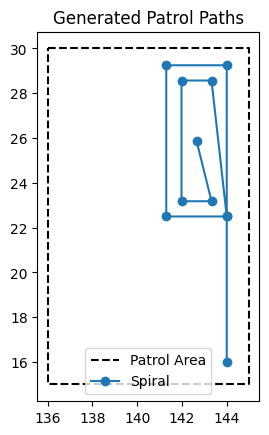

{'Spiral': [(144, 16), (144.0, 22.5), (144.0, 29.25), (141.3, 29.25), (141.3, 22.5), (144.0, 22.5), (143.32, 28.57), (141.98, 28.57), (141.98, 23.18), (143.32, 23.18), (142.65, 25.88)]}


In [169]:
def plot_patrol(polygon, paths_dict):
    x, y = polygon.exterior.xy
    plt.plot(x, y, 'k--', label='Patrol Area')

    for label, path in paths_dict.items():
        px, py = zip(*path)
        plt.plot(px, py, marker='o', label=label)

    plt.gca().set_aspect('equal')
    plt.legend()
    plt.title("Generated Patrol Paths")
    plt.show()

# Generate and plot
area = Polygon([(136,30), (145,30), (145,15),(136,15) ])
current_pos = (144, 16)  # 当前位置

paths = {
    # "Random-patrol":[current_pos] + generate_random_patrol(area,current_pos), 
    # "Bow-shaped-patrol": [current_pos] + generate_bow_patrol(area, current_pos,num_area=5),
    # "Z-patrol": [current_pos] + generate_Z_patrol(area, current_pos,num_slash=4),
    "Spiral":  [current_pos] + generate_spiral_patrol(area, current_pos,num_loops=2)
}

plot_patrol(area, paths)
print(paths)

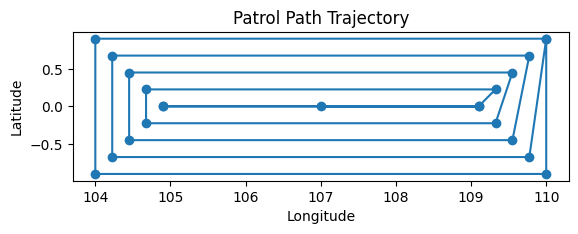

In [158]:
import matplotlib.pyplot as plt

# 重新定义路径
path_lon = [110.0, 110.0, 104.0, 104.0, 110.0, 109.775, 104.225, 104.225,
            109.775, 109.55, 104.45, 104.45, 109.55, 109.325, 104.675,
            104.675, 109.325, 109.1, 104.9, 104.9, 109.1, 107.0]
path_lat = [0.9, -0.9, -0.9, 0.9, 0.9, -0.675, -0.675, 0.675, 0.675,
            -0.45, -0.45, 0.45, 0.45, -0.225, -0.225, 0.225, 0.225,
            -5.551115123125783e-17, -5.551115123125783e-17, 5.551115123125783e-17,
            5.551115123125783e-17, 0.0]

plt.figure()
plt.plot(path_lon, path_lat, marker='o')
plt.gca().set_aspect('equal')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Patrol Path Trajectory')
plt.show()


In [ ]:
import time
import threading
from collections import defaultdict

class CommandLatch:
    """
    dict[entity_id][actor_idx] = remain_step
    remain_step>0 代表本帧禁止覆盖该 Actor。
    """
    def __init__(self):
        self.table = defaultdict(lambda: defaultdict(int))
        self.running = True  # 控制线程运行状态
        self._lock = threading.Lock()  # 确保线程安全

    def tick(self):
        """每秒更新一次冷却时间"""
        self.times = 0
        while self.running:
            with self._lock:
                for ent in list(self.table.keys()):
                    for a_idx in list(self.table[ent].keys()):
                        self.table[ent][a_idx] = max(self.table[ent][a_idx] - 1, 0)
                    if all(v == 0 for v in self.table[ent].values()):
                        del self.table[ent]
            time.sleep(1)  # 每秒更新一次
            self.times += 1
            print(f"Tick thread running...{self.times}")

    def stop(self):
        """停止 tick 线程"""
        self.running = False

    def is_locked(self, ent_id, actor_idx) -> bool:
        with self._lock:
            return self.table[ent_id][actor_idx] > 0

    def lock(self, ent_id, actor_idx, cooldown=None):
        with self._lock:
            cd = cooldown if cooldown is not None else 0
            self.table[ent_id][actor_idx] = cd
            
            
class SimulatedEnv:
    def __init__(self):
        self.latch = CommandLatch()
        self.tick_thread = None

    def reset(self):
        """重置环境并启动 tick 线程"""
        # 停止旧的 tick 线程
        if self.tick_thread:
            self.latch.stop()
            self.tick_thread.join()
        
        # 创建新的 CommandLatch 实例和启动新的 tick 线程
        self.latch = CommandLatch()
        self.tick_thread = threading.Thread(target=self.latch.tick, daemon=True)
        self.tick_thread.start()

    def step(self, ent_id, actor_idx, cooldown):
        """模拟环境的一步操作"""
        if not self.latch.is_locked(ent_id, actor_idx):
            print(f"Entity {ent_id} Actor {actor_idx} is not locked. Executing action.")
            self.latch.lock(ent_id, actor_idx, cooldown)
        else:
            print(f"Entity {ent_id} Actor {actor_idx} is locked. Cannot execute action.")
            

import time
import numpy as np

def main():
    env = SimulatedEnv()
    # episodes = 0
    # num_episodes = 3  # 模拟3个episode

    try:
        # for episode in np.arange(episodes, num_episodes + 1):
        #     print(f"Starting episode {episode}")
        env.reset()

        done = False
        step_count = 0
        while not done:
            # 模拟环境步骤
            env.step(ent_id=1, actor_idx=1, cooldown=3)
            step_count += 1
            print(f"Step {step_count} executed.")
            time.sleep(0.5)
            if step_count >= 50:  # 假设每个episode有5000个步骤
                done = True
    finally:
        # 确保在程序结束时停止 tick 线程
        if env.tick_thread:
            env.latch.stop()
            env.tick_thread.join()
        print("Simulation ended.")

if __name__ == "__main__":
    main()

Starting episode 0
Entity 1 Actor 1 is not locked. Executing action.
Step 1 executed.
Entity 1 Actor 1 is locked. Cannot execute action.
Step 2 executed.
Tick thread running...1
Entity 1 Actor 1 is locked. Cannot execute action.
Step 3 executed.
Entity 1 Actor 1 is locked. Cannot execute action.
Step 4 executed.
Tick thread running...2
Entity 1 Actor 1 is locked. Cannot execute action.
Step 5 executed.
Entity 1 Actor 1 is locked. Cannot execute action.
Step 6 executed.
Tick thread running...3
Entity 1 Actor 1 is not locked. Executing action.
Step 7 executed.
Entity 1 Actor 1 is locked. Cannot execute action.
Step 8 executed.
Tick thread running...4
Entity 1 Actor 1 is locked. Cannot execute action.
Step 9 executed.
Entity 1 Actor 1 is locked. Cannot execute action.
Step 10 executed.
Tick thread running...5
Entity 1 Actor 1 is locked. Cannot execute action.
Step 11 executed.
Entity 1 Actor 1 is locked. Cannot execute action.
Step 12 executed.
Tick thread running...6
Entity 1 Actor 1 is 